In [1]:
!pip install kaggle

from google.colab import files
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [2]:
import torch

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


In [3]:
!kaggle datasets download "paultimothymooney/chest-xray-pneumonia"

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [01:49<00:00, 22.6MB/s]



In [4]:
!unzip chest-xray-pneumonia.zip

Streaming output truncated to the last 5000 lines.
  inflating: chest_xray/train/NORMAL/IM-0435-0001-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0435-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0437-0001-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0437-0001-0002.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0437-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0438-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0439-0001-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0439-0001-0002.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0439-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0440-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0441-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0442-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0444-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0445-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0446-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0447-0001.jpeg  
  inflating:

In [5]:
import os

data_path = "/content/chest_xray"

for split in ["train","test","val"] :
  print(f"\n{split.upper()}")

  for cls in os.listdir(os.path.join(data_path,split)) :
    print(f"{cls} : {len(os.listdir(os.path.join(data_path,split,cls)))}")


TRAIN
NORMAL : 1341
PNEUMONIA : 3875

TEST
NORMAL : 234
PNEUMONIA : 390

VAL
NORMAL : 8
PNEUMONIA : 8


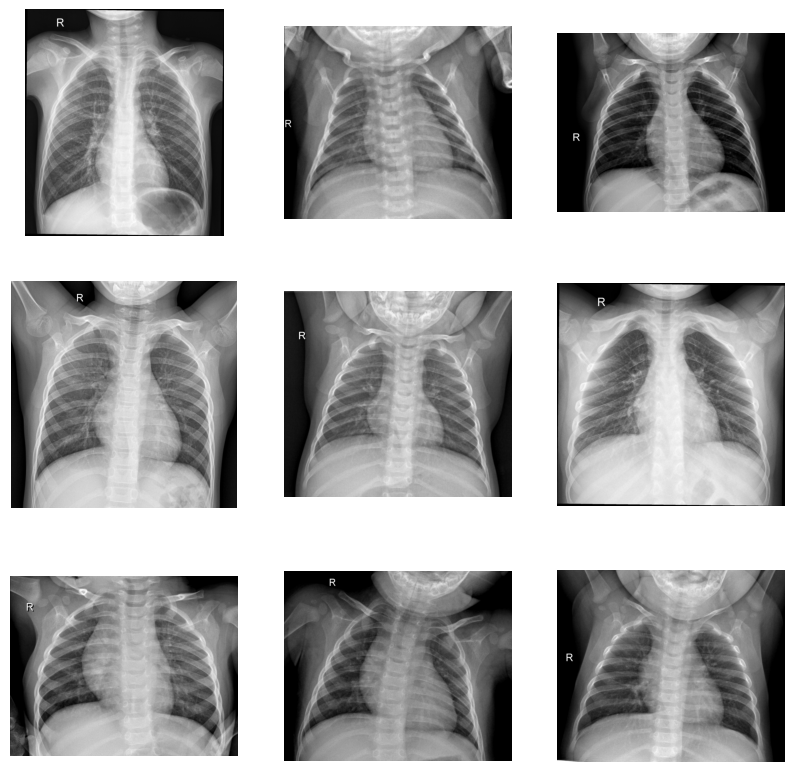

In [6]:
import matplotlib.pyplot as plt
from PIL import Image
import os
import random

folder = "/content/chest_xray/train/NORMAL"

images = random.sample(os.listdir(folder),9)

plt.figure(figsize=(10,10))

for i, img_name in enumerate(images):
  img = Image.open(os.path.join(folder,img_name))
  plt.subplot(3,3,i+1)
  plt.imshow(img,cmap="gray")
  plt.axis("off")

plt.show()

In [7]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(10),
    transforms.Lambda(lambda x:x.convert("RGB")),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5],std=[0.5])
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.Lambda(lambda x:x.convert("RGB")),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5],std=[0.5])
])

In [8]:
from torchvision import datasets

train_data = datasets.ImageFolder(os.path.join(data_path,"train"),transform=train_transform)
test_data = datasets.ImageFolder(os.path.join(data_path,"test"),transform=test_transform)

In [9]:
print(f"Train data : {len(train_data)}")
print(f"Test data : {len(test_data)}")
print(train_data.classes)

Train data : 5216
Test data : 624
['NORMAL', 'PNEUMONIA']


In [10]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_data,batch_size=32,shuffle=True)
test_loader = DataLoader(test_data,batch_size=32,shuffle=False)

In [11]:
def train_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              optimizer: torch.optim.Optimizer) :
  model.train()
  train_loss,train_acc = 0,0

  for batch,(X,y) in enumerate(dataloader) :
    X,y = X.to(device),y.to(device)
    y_pred = model(X)
    loss = loss_fn(y_pred,y.long())
    train_loss += loss.item()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    y_pred_class = torch.argmax(y_pred,dim=1)
    train_acc += (y_pred_class.cpu() == y.cpu()).sum().item()/len(y_pred)

  train_loss = train_loss / len(dataloader)
  train_acc = train_acc / len(dataloader)
  return train_loss,train_acc


def test_step(model : torch.nn.Module,
              dataloader : torch.utils.data.DataLoader,
              loss_fn : torch.nn.Module) :
  model.eval()
  test_loss,test_acc = 0,0

  with torch.inference_mode():
    for batch,(X,y) in enumerate(dataloader) :
      X,y = X.to(device),y.to(device)
      test_pred = model(X)
      loss = loss_fn(test_pred,y.long())
      test_loss += loss.item()

      test_pred_class = torch.argmax(test_pred,dim=1)
      test_acc += (test_pred_class.cpu() == y.cpu()).sum().item()/len(test_pred)

    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
  return test_loss,test_acc

In [12]:
def train (model : torch.nn.Module,
          train_dataloader : torch.utils.data.DataLoader,
          test_dataloader : torch.utils.data.DataLoader,
          optimizer : torch.optim.Optimizer,
          loss_fn : torch.nn.Module,
          epochs : int):

  results = {
          "train_loss" : [],
          "train_acc" : [],
          "test_loss" : [],
          "test_acc" : []
      }


  for epoch in range(epochs) :
    train_loss,train_acc = train_step(model=model,
                                      dataloader=train_dataloader,
                                      loss_fn=loss_fn,
                                      optimizer=optimizer)

    test_loss,test_acc = test_step(model=model,
                                   dataloader=test_dataloader,
                                   loss_fn=loss_fn)


    if epoch % 2 == 0 :
      print(f"Epoch : {epoch+1} | Train Loss : {train_loss:.4f} | Train Acc : {train_acc:.4f} | Test Loss : {test_loss:.4f} | Test Acc : {test_acc:.4f}")

    results["train_loss"].append(train_loss)
    results["train_acc"].append(train_acc)
    results["test_loss"].append(test_loss)
    results["test_acc"].append(test_acc)


  return results

In [13]:
from torchvision import models

model_0 = models.resnet18(weights="DEFAULT")

for param in model_0.parameters() :
  param.requires_grad = False

model_0.fc = torch.nn.Linear(model_0.fc.in_features,2)
model_0 = model_0.to(device)

loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_0.parameters(),lr=0.001)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 195MB/s]


In [14]:
model_0_results = train(model=model_0,
                        train_dataloader=train_loader,
                        test_dataloader=test_loader,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=15)

Epoch : 1 | Train Loss : 0.2968 | Train Acc : 0.8786 | Test Loss : 0.3276 | Test Acc : 0.8594
Epoch : 3 | Train Loss : 0.1637 | Train Acc : 0.9339 | Test Loss : 0.3576 | Test Acc : 0.8562
Epoch : 5 | Train Loss : 0.1503 | Train Acc : 0.9425 | Test Loss : 0.3864 | Test Acc : 0.8500
Epoch : 7 | Train Loss : 0.1419 | Train Acc : 0.9457 | Test Loss : 0.3802 | Test Acc : 0.8625
Epoch : 9 | Train Loss : 0.1305 | Train Acc : 0.9492 | Test Loss : 0.4049 | Test Acc : 0.8594
Epoch : 11 | Train Loss : 0.1267 | Train Acc : 0.9534 | Test Loss : 0.5475 | Test Acc : 0.8141
Epoch : 13 | Train Loss : 0.1218 | Train Acc : 0.9503 | Test Loss : 0.6452 | Test Acc : 0.8016
Epoch : 15 | Train Loss : 0.1343 | Train Acc : 0.9473 | Test Loss : 0.4611 | Test Acc : 0.8484


In [15]:
model_1 = models.efficientnet_b0(weights="DEFAULT")
for param in model_1.parameters() :
  param.requires_grad = False

model_1.classifier[1] = torch.nn.Linear(model_1.classifier[1].in_features,2)
model_1 = model_1.to(device)

loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_1.parameters(),lr=0.001)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 192MB/s]


In [16]:
model_1_results = train(model=model_1,
                        train_dataloader=train_loader,
                        test_dataloader=test_loader,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=15)

Epoch : 1 | Train Loss : 0.2662 | Train Acc : 0.8936 | Test Loss : 0.3307 | Test Acc : 0.8578
Epoch : 3 | Train Loss : 0.1637 | Train Acc : 0.9390 | Test Loss : 0.3133 | Test Acc : 0.8844
Epoch : 5 | Train Loss : 0.1456 | Train Acc : 0.9429 | Test Loss : 0.3076 | Test Acc : 0.8875
Epoch : 7 | Train Loss : 0.1393 | Train Acc : 0.9482 | Test Loss : 0.3032 | Test Acc : 0.8844
Epoch : 9 | Train Loss : 0.1414 | Train Acc : 0.9444 | Test Loss : 0.3216 | Test Acc : 0.8812
Epoch : 11 | Train Loss : 0.1423 | Train Acc : 0.9465 | Test Loss : 0.3332 | Test Acc : 0.8719
Epoch : 13 | Train Loss : 0.1397 | Train Acc : 0.9450 | Test Loss : 0.3410 | Test Acc : 0.8703
Epoch : 15 | Train Loss : 0.1301 | Train Acc : 0.9525 | Test Loss : 0.3068 | Test Acc : 0.8984


In [17]:
mode_2 = models.mobilenet_v3_small(weights="DEFAULT")

for param in mode_2.parameters() :
  param.requires_grad = False

mode_2.classifier[3] = torch.nn.Linear(mode_2.classifier[3].in_features,2)
mode_2 = mode_2.to(device)

loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(mode_2.parameters(),lr=0.001)

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 190MB/s]


In [18]:
model_2_results = train(model=mode_2,
                        train_dataloader=train_loader,
                        test_dataloader=test_loader,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=15)

Epoch : 1 | Train Loss : 0.2484 | Train Acc : 0.9038 | Test Loss : 0.5001 | Test Acc : 0.7594
Epoch : 3 | Train Loss : 0.1415 | Train Acc : 0.9425 | Test Loss : 0.4795 | Test Acc : 0.8000
Epoch : 5 | Train Loss : 0.1278 | Train Acc : 0.9498 | Test Loss : 0.3307 | Test Acc : 0.8703
Epoch : 7 | Train Loss : 0.1314 | Train Acc : 0.9498 | Test Loss : 0.3892 | Test Acc : 0.8453
Epoch : 9 | Train Loss : 0.1241 | Train Acc : 0.9503 | Test Loss : 0.4131 | Test Acc : 0.8313
Epoch : 11 | Train Loss : 0.1353 | Train Acc : 0.9482 | Test Loss : 0.4699 | Test Acc : 0.8203
Epoch : 13 | Train Loss : 0.1329 | Train Acc : 0.9496 | Test Loss : 0.4567 | Test Acc : 0.8250
Epoch : 15 | Train Loss : 0.1203 | Train Acc : 0.9546 | Test Loss : 0.4382 | Test Acc : 0.8313


In [19]:
torch.save(model_0.state_dict(),"model_0_resnet.pth")
torch.save(model_1.state_dict(),"model_1_efficientnet.pth")
torch.save(mode_2.state_dict(),"model_2_mobilenet.pth")

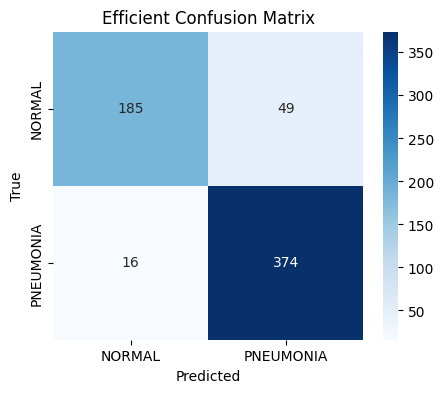

In [20]:
#Generate the confution matrix of EFFicientNET

import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

model_1.eval()

y_true = []
y_pred = []

with torch.inference_mode():
    for batch,(X,y) in enumerate(test_loader) :
      X,y = X.to(device),y.to(device)
      test_pred = model_1(X)
      test_pred_class = torch.argmax(test_pred,dim=1)
      y_true.extend(y.cpu().numpy())
      y_pred.extend(test_pred_class.cpu().numpy())

cm = confusion_matrix(y_true,y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=test_data.classes,yticklabels=test_data.classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Efficient Confusion Matrix")
plt.show()

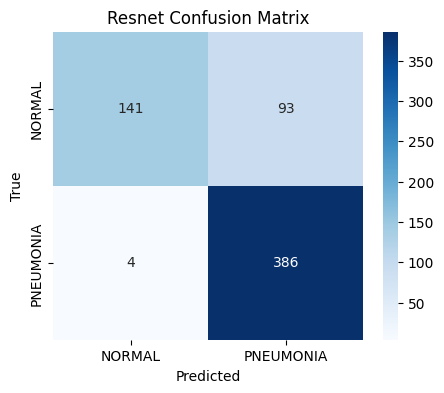

In [21]:
model_0.eval()

y_true = []
y_pred = []

with torch.inference_mode():
    for batch,(X,y) in enumerate(test_loader):
      X,y = X.to(device),y.to(device)
      test_pred = model_0(X)
      test_pred_class = torch.argmax(test_pred,dim=1)
      y_true.extend(y.cpu().numpy())
      y_pred.extend(test_pred_class.cpu().numpy())

cm = confusion_matrix(y_true,y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=test_data.classes,yticklabels=test_data.classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Resnet Confusion Matrix")
plt.show()

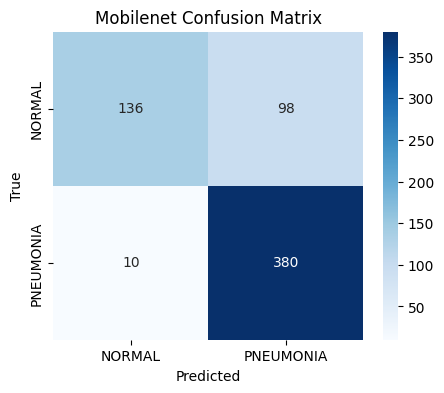

In [22]:
mode_2.eval()

y_true = []
y_pred = []

with torch.inference_mode():
    for batch,(X,y) in enumerate(test_loader):
      X,y = X.to(device),y.to(device)
      test_pred = mode_2(X)
      test_pred_class = torch.argmax(test_pred,dim=1)

      y_true.extend(y.cpu().numpy())
      y_pred.extend(test_pred_class.cpu().numpy())

cm = confusion_matrix(y_true,y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=test_data.classes,yticklabels=test_data.classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Mobilenet Confusion Matrix")
plt.show()

In [23]:
import matplotlib.pyplot as plt

def plot_curve(results) :

  plt.figure(figsize=(10,10))


  plt.subplot(2,1,1)
  plt.plot(results["train_loss"],label="train_loss")
  plt.plot(results["test_loss"],label="test_loss")
  plt.title("Loss")
  plt.legend()
  plt.xlabel("Epochs")
  plt.ylabel("Loss")

  plt.subplot(2,1,2)
  plt.plot(results["train_acc"],label="train_acc")
  plt.plot(results["test_acc"],label="test_acc")
  plt.title("Accuracy")
  plt.legend()
  plt.xlabel("Epochs")
  plt.ylabel("Accuracy")

  plt.show()

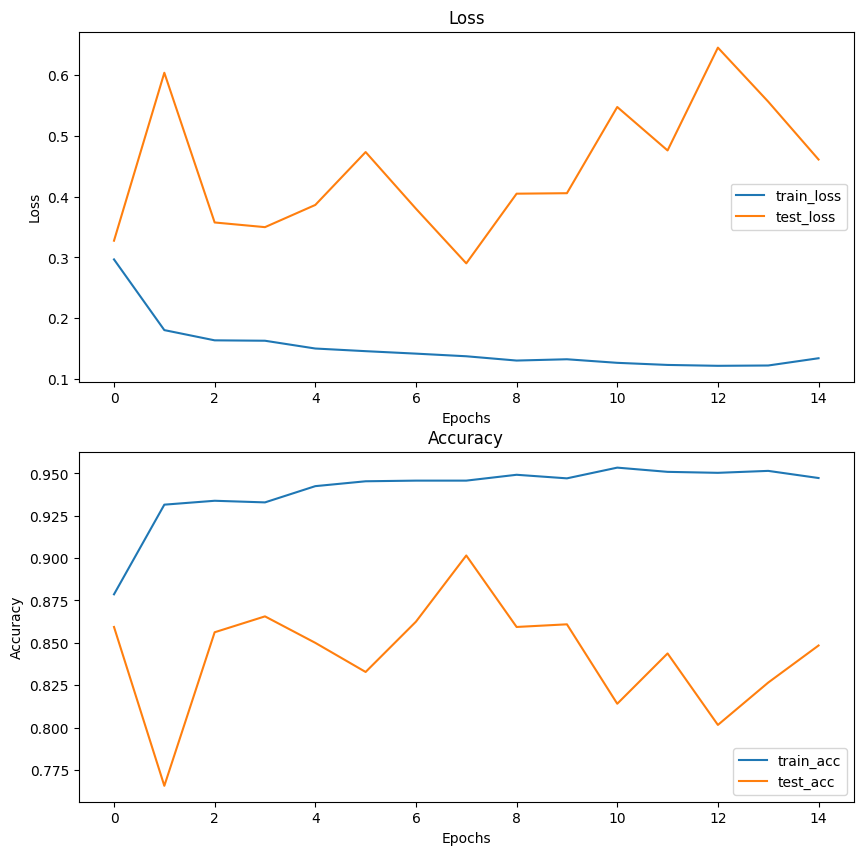

In [24]:
plot_curve(model_0_results)

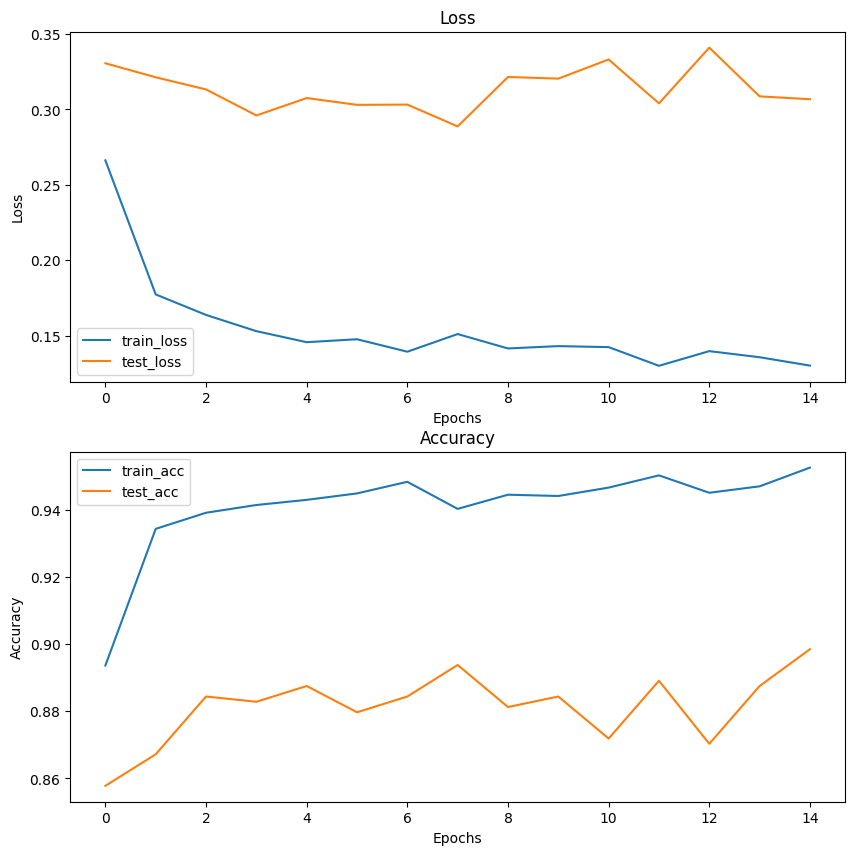

In [25]:
plot_curve(model_1_results)

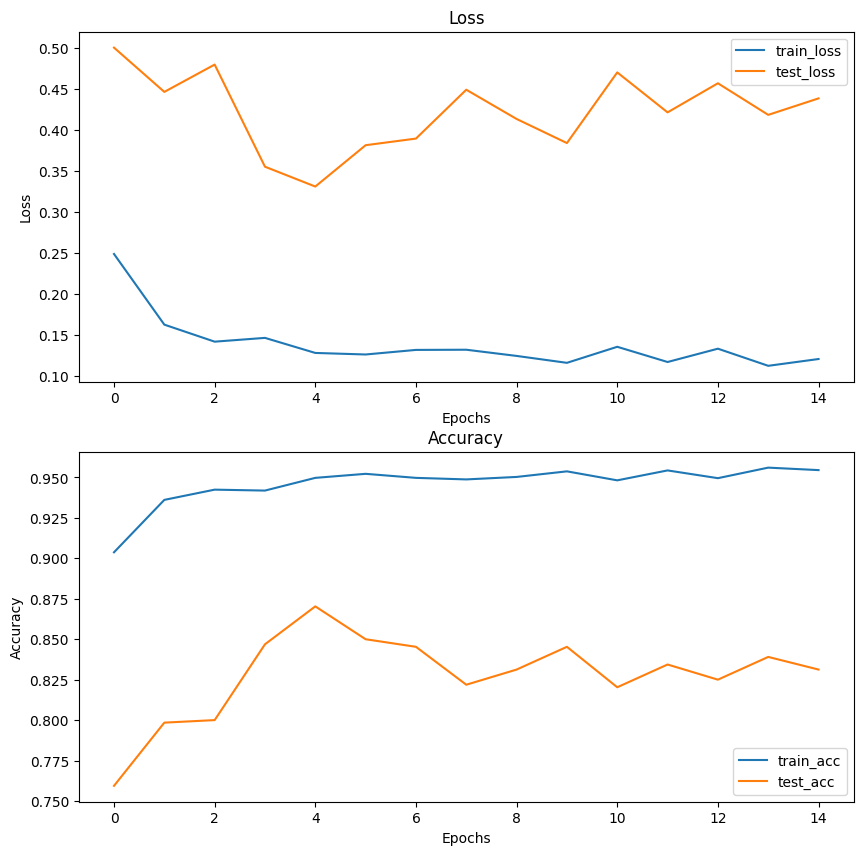

In [26]:
plot_curve(model_2_results)


In [27]:
from google.colab import files
files.download("model_0_resnet.pth")
files.download("model_1_efficientnet.pth")
files.download("model_2_mobilenet.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>